In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Cleaning

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/chatgpt_reviews.csv')

In [3]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [4]:
# Handle missing values
df.columns = df.columns.str.lower().str.replace(" ","_")
print(df.columns)

Index(['review_id', 'review', 'ratings', 'review_date'], dtype='object')


In [5]:
df.isnull().sum()

,0
review_id,0
review,6
ratings,0
review_date,0


In [6]:
df['review'] = df['review'].fillna("")
df.isnull().sum()

,0
review_id,0
review,0
ratings,0
review_date,0


In [7]:
df['review_date'] = pd.to_datetime(df['review_date'],errors ='coerce')
df['ratings'] = pd.to_numeric(df['ratings'],errors ='coerce')



In [8]:
df.dtypes

,0
review_id,object
review,object
ratings,int64
review_date,datetime64[ns]


Sentiment Analysis

In [9]:
!pip install textblob

In [10]:
# Sentiment Analysis

#Calculate Polarity

df['polarity'] = df['review'].apply(lambda review: TextBlob(review).sentiment.polarity)
df[['review','polarity']].head()

,review,polarity
0,good,0.7000
1,good,0.7000
2,nice app,0.6000
3,"nice, ig",0.6000
4,"this is a great app, the bot is so accurate to...",0.4125


In [11]:
# Calcuulate Subjectivity

df['subjectivity'] = df['review'].apply(lambda review: TextBlob(review).sentiment.subjectivity)
df[['review','subjectivity']].head()


,review,subjectivity
0,good,0.600000
1,good,0.600000
2,nice app,1.000000
3,"nice, ig",1.000000
4,"this is a great app, the bot is so accurate to...",0.542949


In [12]:
df[['review','polarity','subjectivity']].head()

,review,polarity,subjectivity
0,good,0.7000,0.600000
1,good,0.7000,0.600000
2,nice app,0.6000,1.000000
3,"nice, ig",0.6000,1.000000
4,"this is a great app, the bot is so accurate to...",0.4125,0.542949


In [13]:
def get_sentiment(polarity):
  if polarity < 0:
    return 'Negative'
  elif polarity == 0:
      return 'Neutral'
  else:
    return 'Positive'

df['sentiment'] = df['polarity'].apply(get_sentiment)
df[['review','polarity','subjectivity','sentiment']].head()

,review,polarity,subjectivity,sentiment
0,good,0.7000,0.600000,Positive
1,good,0.7000,0.600000,Positive
2,nice app,0.6000,1.000000,Positive
3,"nice, ig",0.6000,1.000000,Positive
4,"this is a great app, the bot is so accurate to...",0.4125,0.542949,Positive


In [14]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,150122
Neutral,38450
Negative,8155


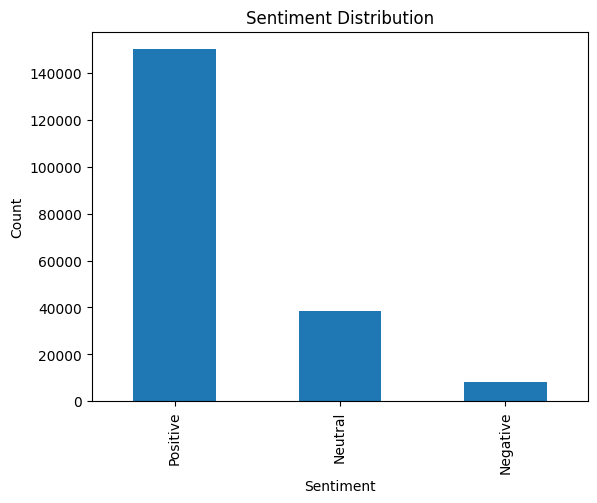

In [15]:
# Visualization

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2969/642058754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x='ratings' ,palette ='Set2')


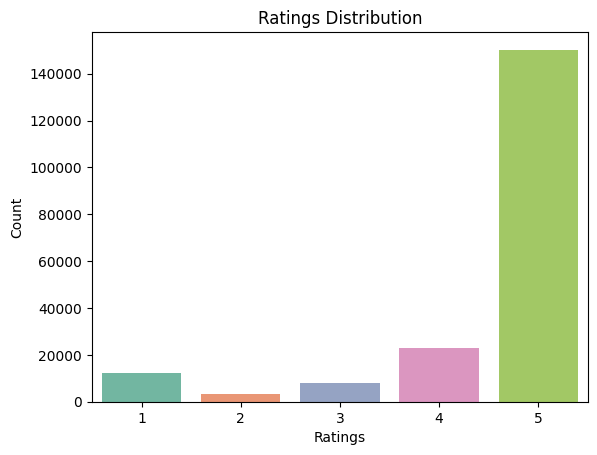

In [16]:
# Ratings Distribution

import seaborn as sns

sns.countplot(data = df, x='ratings' ,palette ='Set2')
plt.title("Ratings Distribution")
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

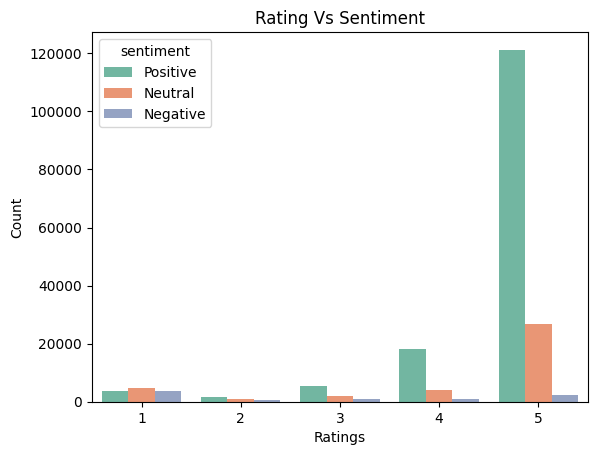

In [24]:
# Rating Vs Sentiment

sns.countplot(data = df, x='ratings', hue='sentiment',palette ='Set2')
plt.title("Rating Vs Sentiment")
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2969/2187292219.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df, x='polarity', kde=True,palette ='Set2')


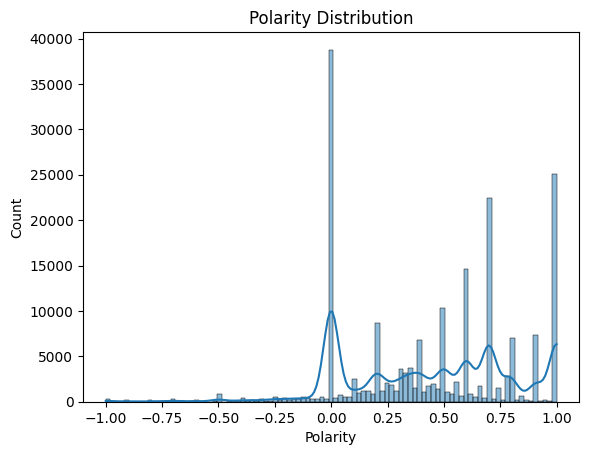

In [26]:
# Polarity Distribution

sns.histplot(data = df, x='polarity', kde=True,palette ='Set2')
plt.title("Polarity Distribution")
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2969/2234687822.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df, x='subjectivity', kde=True,palette ='Set2')


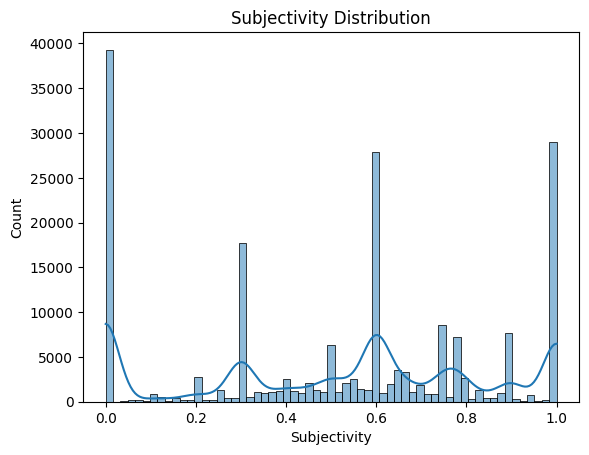

In [27]:
# Subjectivity Distribution

sns.histplot(data = df, x='subjectivity', kde=True,palette ='Set2')
plt.title("Subjectivity Distribution")
plt.xlabel('Subjectivity')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2969/3761999525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x='ratings', y='polarity',palette ='Set2')


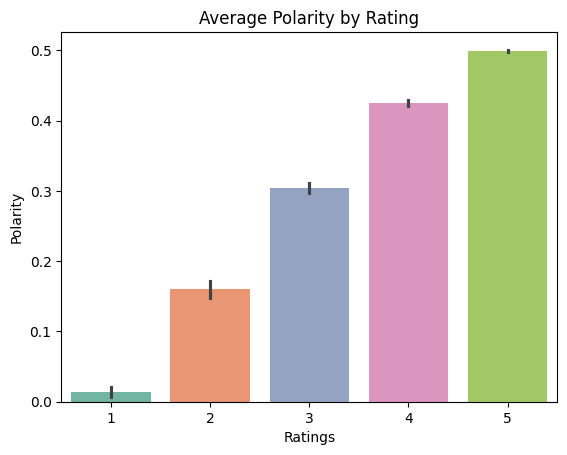

In [25]:
# Average Polarity by Rating

sns.(data = df, x='ratings', y='polarity',palette ='Set2')
plt.title("Average Polarity by Rating")
plt.xlabel('Ratings')
plt.ylabel('Polarity')
plt.show()

In [18]:
# Filter and analyze positively rated reviews.

positive_reviews = df[df['sentiment'] == 'Positive']
positive_reviews.head()

,review_id,review,ratings,review_date,polarity,subjectivity,sentiment
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,0.600000,Positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,0.600000,Positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,1.000000,Positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,1.000000,Positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,0.542949,Positive


In [35]:
#  Positive keywords and phrases

text = " ".join(positive_reviews['review'])
text = text.lower()

words = text.split()

from wordcloud import STOPWORDS
stopwords = set(STOPWORDS)

words = [word for word in words if word not in stopwords]

from collections import Counter
word_count = Counter(words)

print(word_count.most_common(20))


[('app', 37717), ('good', 37329), ('best', 17741), ('nice', 13305), ('great', 10837), ('ai', 9115), ('helpful', 8600), ('love', 8467), ('amazing', 7315), ('really', 7038), ('chatgpt', 6844), ('useful', 6842), ('excellent', 5757), ('use', 5415), ('chat', 4468), ('awesome', 4335), ('much', 3529), ('👍', 3476), ('gpt', 3348), ('help', 3302)]


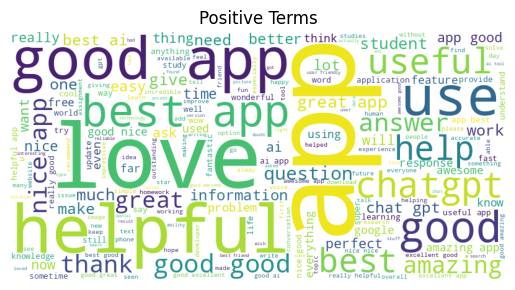

In [43]:
# Visualize Positive Terms
# 1. WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Terms')
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


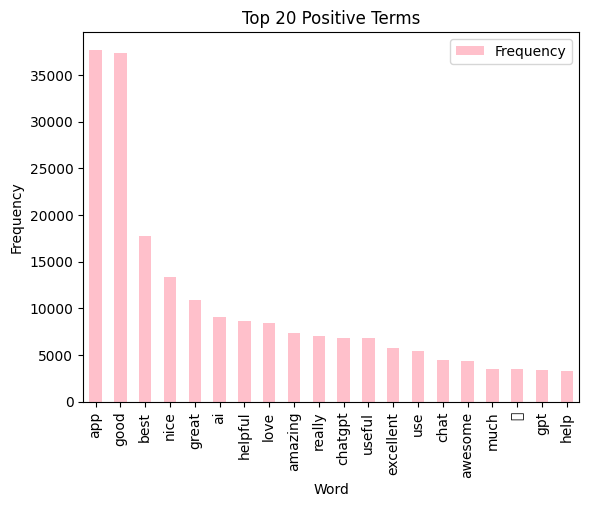

In [46]:
# 2. Frequency Plot

top_words = word_count.most_common(20)
top_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
top_df.plot(kind='bar', x='Word', y='Frequency', color='pink')
plt.title('Top 20 Positive Terms')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.show()